# Bias & Fairness Assessment  
### NovaCred Credit Applications Dataset (Cleaned)

This notebook evaluates **fairness risks in credit approvals** using the **cleaned dataset** produced by the Data Engineering pipeline (`01-data-quality.ipynb`).

We focus on patterns required in the project brief:
- **Gender disparate impact (DI)**
- **Age discrimination patterns**
- **ZIP code as a proxy feature**
- **Interaction effects (age × gender)**

**Important:** We intentionally do **not** use direct identifiers (name/email/SSN/IP) in any analysis.

## Setup

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

## Load cleaned dataset

We load the cleaned CSV created in `01-data-quality.ipynb`.  

In [42]:
DATA_PATH = "../data/cleaned_credit_applications.csv"
df = pd.read_csv(DATA_PATH)

df.shape

(500, 43)

In [43]:
df.head(3)

,_id,applicant_info_full_name,applicant_info_email,applicant_info_ssn,applicant_info_ip_address,applicant_info_gender,applicant_info_date_of_birth,applicant_info_zip_code,financials_annual_income,financials_credit_history_months,financials_debt_to_income,financials_savings_balance,decision_loan_approved,loan_purpose,decision_interest_rate,decision_approved_amount,age_years,spend_shopping,spend_rent,spend_alcohol,spend_dining,spend_healthcare,spend_fitness,spend_entertainment,spend_insurance,spend_travel,spend_transportation,spend_utilities,spend_groceries,spend_education,spend_adult_entertainment,spend_gambling,annual_income_missing,savings_balance_missing,debt_to_income_missing,savings_balance_zero,credit_history_suspicious,dob_missing,email_missing,ssn_missing,email_valid,ssn_duplicate,needs_review
0,app_200,Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,Male,2001-03-09,10036.0,73000.0,23.0,0.20,31212.0,False,NaN,NaN,NaN,25.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,True,False,False
1,app_037,Brandon Walker,brandon.walker2@yahoo.com,425-69-4784,10.1.102.112,Male,1992-03-31,10032.0,78000.0,51.0,0.18,17915.0,False,NaN,NaN,NaN,33.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,True,False,False
2,app_215,Scott Moore,scott.moore94@mail.com,370-78-5178,10.240.193.250,Male,1989-10-24,10075.0,61000.0,41.0,0.21,37909.0,True,vacation,3.7,59000.0,36.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,True,False,False


## 1) Scope: exclude direct identifiers from analysis outputs

Privacy/pseudonymization is handled in `03-privacy-demo.ipynb`.  
Here we simply avoid using direct identifiers (name/email/SSN/IP) in fairness analysis.

In [44]:
pii_cols = [
    "applicant_info_full_name",
    "applicant_info_email",
    "applicant_info_ssn",
    "applicant_info_ip_address",
]

df_bias = df.drop(columns=[c for c in pii_cols if c in df.columns]).copy()
df_bias.shape

(500, 39)

## 2) Sanity checks

We report group counts for fairness-critical fields.  
This is essential for interpreting DI and subgroup comparisons.

In [45]:
summary = pd.Series({
    "n_rows": len(df_bias),
    "approval_rate_overall": df_bias["decision_loan_approved"].mean(),
    "n_unique_zip": df_bias["applicant_info_zip_code"].nunique(),
})
summary

n_rows                   500.000
approval_rate_overall      0.584
n_unique_zip             195.000
dtype: float64

In [46]:
df_bias["applicant_info_gender"].value_counts(dropna=False)

applicant_info_gender
Female    250
Male      247
NaN         3
Name: count, dtype: int64

## 3) Disparate Impact (DI)

Selection rate for a group = mean(loan_approved)

We compute:
- **DI = ApprovalRate(Female) / ApprovalRate(Male)**

**Four-fifths rule (screening heuristic):**
- Flag potential adverse impact when **DI < 0.80** (not proof of discrimination).

### DI Helper Functions

In [71]:
def group_selection_rate(df_in: pd.DataFrame, outcome_col: str, group_col: str) -> pd.Series:
    return df_in.groupby(group_col)[outcome_col].mean()

def disparate_impact(df_in: pd.DataFrame, outcome_col: str, group_col: str, unpriv: str, priv: str) -> float:
    rates = group_selection_rate(df_in, outcome_col, group_col)
    return float(rates.loc[unpriv] / rates.loc[priv])

## 4) Issue 1: Gender Disparate Impact

We report:
- group counts (Female/Male)
- approval rates
- DI (Female/Male)
- four-fifths rule flag (DI < 0.80)

In [ ]:
df_gender = df_bias[df_bias["applicant_info_gender"].isin(["Female", "Male"])].copy()

gender_counts = df_gender["applicant_info_gender"].value_counts()
gender_rates = group_selection_rate(df_gender, "decision_loan_approved", "applicant_info_gender")
di_female_over_male = disparate_impact(df_gender, "decision_loan_approved", "applicant_info_gender", "Female", "Male")

di_flag = di_female_over_male < 0.80

print("Gender group sizes:")
print(gender_counts)
print()

print("Approval rates by gender:")
print(gender_rates)
print()

print(f"Disparate Impact (Female / Male): {di_female_over_male:.3f}")
print(f"Four-fifths rule triggered (DI < 0.80): {di_flag}")

Gender group sizes:
applicant_info_gender
Female    250
Male      247
Name: count, dtype: int64

Approval rates by gender:
applicant_info_gender
Female    0.508000
Male      0.659919
Name: decision_loan_approved, dtype: float64

Disparate Impact (Female / Male): 0.770
Four-fifths rule triggered (DI < 0.80): True


## Interpretation of Gender Disparity Results

The dataset includes **250 female applicants** and **247 male applicants**, so the gender distribution in the sample is relatively balanced.

However, the approval outcomes differ between the two groups. The approval rate for female applicants is **50.8%**, while the approval rate for male applicants is **65.9%**. This leads to a **Disparate Impact (DI) ratio of 0.77** when comparing female applicants to male applicants.

According to the **four-fifths rule**, a DI value below **0.80** may indicate potential adverse impact. Since the observed DI is **0.77**, the approval rate for female applicants is noticeably lower than for male applicants in this dataset.

This result does not by itself prove that the decision process is discriminatory. However, it does highlight a clear difference in outcomes between genders. To better understand this pattern, the following sections examine approval rates across **age groups**, possible **interaction effects**, and whether **other variables such as ZIP code may act as proxies** for protected characteristics.

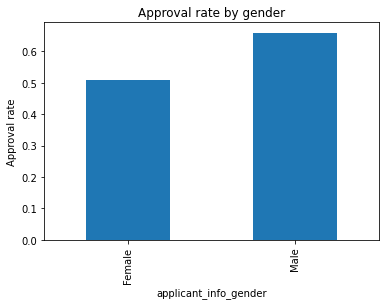

In [50]:
gender_rates.reindex(["Female", "Male"]).plot(kind="bar")
plt.ylabel("Approval rate")
plt.title("Approval rate by gender")
plt.show()

## Fairness metric cross-check

In addition to the disparate impact ratio, we compute demographic parity difference using Fairlearn. This measures the absolute gap in selection rates between groups and complements the ratio-based DI measure.

In [74]:
from fairlearn.metrics import demographic_parity_difference

y = df_gender["decision_loan_approved"].astype(int)
s = df_gender["applicant_info_gender"]

# We use observed approval decisions as the outcome under review.
dp_diff = demographic_parity_difference(
    y_true=y,
    y_pred=y,
    sensitive_features=s
)

print(f"Demographic parity difference: {dp_diff:.3f}")

Demographic parity difference: 0.152


## Statistical test: gender and approval outcome

To support the approval rate comparison, this section tests whether loan approval outcomes are associated with gender.

A chi-square test of independence is used because both variables are categorical: gender is grouped into female and male applicants, and the decision outcome is either approved or not approved.

In [86]:
from scipy.stats import chi2_contingency

gender_approval_table = pd.crosstab(
    df_gender["applicant_info_gender"],
    df_gender["decision_loan_approved"]
)

chi2, p_value, dof, expected = chi2_contingency(gender_approval_table)

print("Contingency table: gender vs approval")
display(gender_approval_table)

print(f"Chi-square statistic: {chi2:.3f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p_value:.4f}")

Contingency table: gender vs approval


decision_loan_approved,False,True
applicant_info_gender,,
Female,123,127
Male,84,163


Chi-square statistic: 11.182
Degrees of freedom: 1
P-value: 0.0008


### Comment

The chi-square test examines whether loan approval outcomes are independent of applicant gender.

The contingency table shows that **127 out of 250 female applicants were approved (50.8%)**, while **163 out of 247 male applicants were approved (65.9%)**. This already suggests that approval rates differ between the two groups.

The chi-square test produces a **χ² statistic of 11.182** with **1 degree of freedom** and a **p-value of 0.0008**. Since the p-value is well below the common significance level of **0.05**, we reject the null hypothesis that gender and loan approval are independent.

This result indicates that **approval outcomes are statistically associated with gender in this dataset**, which supports the earlier fairness analysis where the **disparate impact ratio was below the four-fifths threshold**.

## 5) Issue 2: Age-based patterns

We bucket ages and compare approval rates across age buckets.

In [65]:
df_bias["age_years"] = pd.to_numeric(df_bias["age_years"], errors="coerce")
df_bias["age_years"].describe()

count    495.000000
mean      41.232929
std       10.944332
min       23.400000
25%       32.400000
50%       39.500000
75%       47.550000
max       67.400000
Name: age_years, dtype: float64

In [66]:
bins = [18, 25, 35, 45, 55, 65, 200]
labels = ["18-24", "25-34", "35-44", "45-54", "55-64", "65+"]

df_age = df_bias.copy()
df_age["age_bucket"] = pd.cut(df_age["age_years"], bins=bins, labels=labels, right=False)

age_counts = df_age["age_bucket"].value_counts().sort_index()
age_rates = df_age.groupby("age_bucket")["decision_loan_approved"].mean().sort_index()

age_counts, age_rates

/var/folders/cb/178szk3j0w7_ptppcgsj5yk00000gn/T/ipykernel_5432/4000937539.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_rates = df_age.groupby("age_bucket")["decision_loan_approved"].mean().sort_index()


(age_bucket
 18-24     11
 25-34    149
 35-44    174
 45-54     92
 55-64     56
 65+       13
 Name: count, dtype: int64,
 age_bucket
 18-24    0.545455
 25-34    0.442953
 35-44    0.672414
 45-54    0.630435
 55-64    0.625000
 65+      0.538462
 Name: decision_loan_approved, dtype: float64)

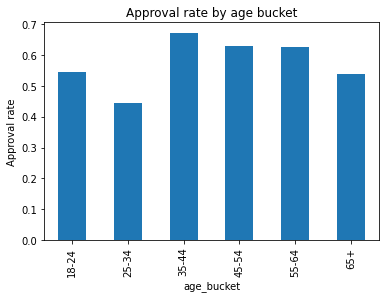

In [64]:
ax = age_rates.plot(kind="bar")
ax.set_ylabel("Approval rate")
ax.set_title("Approval rate by age bucket")
plt.show()

## Interpretation of Approval Rates by Age Group

The approval rates are not the same across age groups, which suggests that age may be related to loan decisions in this dataset.

The **25–34** group has the lowest approval rate at around **44.3%**, while the **35–44** group has the highest at about **67.2%**. Applicants in the **45–54** and **55–64** groups also have relatively high approval rates, both above **62%**. In contrast, the **18–24** and **65+** groups are closer to the middle, with approval rates around **54%**.

This pattern suggests that applicants in the middle age ranges tend to receive approvals more often than younger applicants and those in the 25–34 group in particular. At the same time, the smallest groups in the data are **18–24** and **65+**, so those results should be interpreted with a bit more caution because they are based on fewer observations.

Overall, the results show that approval outcomes vary across age groups, which makes age an important factor to examine further. The next step is to check whether these patterns also differ by **gender within age groups**, since interaction effects can reveal disparities that are not visible when each variable is looked at separately.

## 6) Interaction effects (age × gender)

To go beyond overall DI, we test whether approval gaps differ across **age buckets** (interaction effect).

In [54]:
df_age_gender = df_age[df_age["applicant_info_gender"].isin(["Female", "Male"])].copy()

age_gender_rates = (
    df_age_gender
    .groupby(["age_bucket", "applicant_info_gender"])["decision_loan_approved"]
    .mean()
    .unstack()
    .reindex(columns=["Female", "Male"])
)

age_gender_rates

/var/folders/cb/178szk3j0w7_ptppcgsj5yk00000gn/T/ipykernel_5432/794387973.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_age_gender


applicant_info_gender,Female,Male
age_bucket,,
18-24,0.500000,0.600000
25-34,0.333333,0.563380
35-44,0.621951,0.717391
45-54,0.581395,0.666667
55-64,0.548387,0.720000
65+,0.500000,0.600000


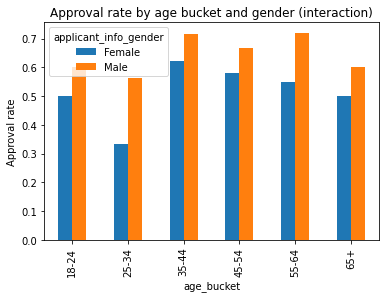

In [55]:
ax = age_gender_rates.plot(kind="bar")
ax.set_ylabel("Approval rate")
ax.set_title("Approval rate by age bucket and gender (interaction)")
plt.show()

## Interpretation of Interaction Effects Between Age and Gender

Looking at age and gender together gives a clearer picture than looking at each variable separately. Across all age groups in the table, **male applicants have a higher approval rate than female applicants**, which suggests that the gender gap is not limited to just one part of the dataset.

The gap is especially noticeable in the **25–34** group, where the approval rate is about **33.3% for female applicants** compared with **56.3% for male applicants**. A clear difference also appears in the **55–64** group, where female applicants have an approval rate of about **54.8%** and male applicants about **72.0%**. In the other age groups, the same pattern remains, even if the size of the gap is smaller.

This matters because it shows that the overall gender disparity is not being driven by only one age category. Instead, the lower approval rate for female applicants appears quite consistently across the age buckets shown here. That makes the pattern more concerning, since it suggests the disparity is broad rather than isolated.

At the same time, some age groups contain fewer observations than others, so the exact rates in the smallest groups should be interpreted with some caution. Even so, the interaction analysis strengthens the earlier result by showing that differences in approval outcomes remain visible when gender is examined within age groups.

## 7) Proxy discrimination analysis: ZIP code

ZIP code is not a protected attribute, but geographic information can sometimes act as a proxy for demographic differences. 

A simple ranking of ZIP-level approval rates is not very informative when many ZIP codes appear only once or twice in the data, because those rates are unstable. For that reason, this section first checks how many observations each ZIP code has, then focuses on ZIP codes with a minimum number of applications.

The analysis has two parts:
1. Compare approval rates across ZIP codes after filtering out very small groups
2. Check whether ZIP-level gender composition is related to ZIP-level approval rates

In [76]:
zip_counts = (
    df_bias["applicant_info_zip_code"]
    .value_counts(dropna=False)
    .rename_axis("applicant_info_zip_code")
    .reset_index(name="count")
)

print(f"Number of unique ZIP codes: {df_bias['applicant_info_zip_code'].nunique(dropna=True)}")
print()
print("ZIP code group sizes:")
display(zip_counts.head(10))

Number of unique ZIP codes: 195

ZIP code group sizes:


,applicant_info_zip_code,count
0,10048.0,8
1,10096.0,7
2,90284.0,7
3,10019.0,6
4,10020.0,6
5,10004.0,6
6,10057.0,6
7,90218.0,5
8,10002.0,5
9,10012.0,5


### ZIP-level approval rates

To reduce noise from very small groups, the approval rate analysis below keeps only ZIP codes with at least a minimum number of applications.

In [77]:
df_zip = df_bias.dropna(subset=["applicant_info_zip_code", "decision_loan_approved"]).copy()

zip_stats = (
    df_zip
    .groupby("applicant_info_zip_code")["decision_loan_approved"]
    .agg(["count", "mean"])
    .rename(columns={"mean": "approval_rate"})
)

MIN_N = 5
zip_stats_filtered = zip_stats[zip_stats["count"] >= MIN_N].sort_values("approval_rate", ascending=False)

print(f"Total ZIP codes with at least 1 application: {zip_stats.shape[0]}")
print(f"ZIP codes with at least {MIN_N} applications: {zip_stats_filtered.shape[0]}")
print()

print("Highest approval rates among filtered ZIP codes:")
display(zip_stats_filtered.head(10))

print("Lowest approval rates among filtered ZIP codes:")
display(zip_stats_filtered.tail(10))

Total ZIP codes with at least 1 application: 195
ZIP codes with at least 5 applications: 19

Highest approval rates among filtered ZIP codes:


,count,approval_rate
applicant_info_zip_code,,
10004.0,6,1.000000
10012.0,5,1.000000
10092.0,5,1.000000
10070.0,5,0.800000
90218.0,5,0.800000
90261.0,5,0.800000
90252.0,5,0.800000
10048.0,8,0.750000
10020.0,6,0.666667


Lowest approval rates among filtered ZIP codes:


,count,approval_rate
applicant_info_zip_code,,
90273.0,5,0.600000
90237.0,5,0.600000
10002.0,5,0.600000
10041.0,5,0.600000
10057.0,6,0.500000
90284.0,7,0.428571
10003.0,5,0.400000
10019.0,6,0.333333
10096.0,7,0.285714


### Visual: distribution of approval rates across ZIP codes

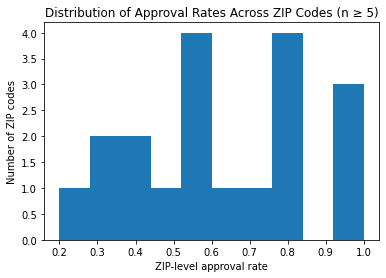

In [91]:
ax = zip_stats_filtered["approval_rate"].plot(kind="hist", bins=10)
ax.set_xlabel("ZIP-level approval rate")
ax.set_ylabel("Number of ZIP codes")
ax.set_title(f"Distribution of Approval Rates Across ZIP Codes (n ≥ {MIN_N})")
plt.show()

### ZIP gender composition and approval rates

To examine whether ZIP code may be acting as a proxy for gender, we calculate two ZIP-level measures:
- **female share**: proportion of applicants in the ZIP who are female
- **approval rate**: proportion of applications approved in the ZIP

We then compare these values across ZIP codes with enough observations.

In [81]:
df_zip_gender = df_bias.dropna(
    subset=["applicant_info_zip_code", "applicant_info_gender", "decision_loan_approved"]
).copy()

df_zip_gender = df_zip_gender[
    df_zip_gender["applicant_info_gender"].isin(["Female", "Male"])
].copy()

zip_proxy = (
    df_zip_gender
    .groupby("applicant_info_zip_code")
    .agg(
        count=("decision_loan_approved", "size"),
        approval_rate=("decision_loan_approved", "mean"),
        female_share=("applicant_info_gender", lambda s: (s == "Female").mean())
    )
)

zip_proxy_filtered = zip_proxy[zip_proxy["count"] >= MIN_N].copy()

print(f"ZIP codes available for proxy analysis (n ≥ {MIN_N}): {zip_proxy_filtered.shape[0]}")
display(zip_proxy_filtered.head(10))

ZIP codes available for proxy analysis (n ≥ 5): 19


,count,approval_rate,female_share
applicant_info_zip_code,,,
10002.0,5,0.600000,0.000000
10003.0,5,0.400000,0.200000
10004.0,6,1.000000,0.000000
10012.0,5,1.000000,0.000000
10019.0,6,0.333333,0.166667
10020.0,6,0.666667,0.000000
10041.0,5,0.600000,0.000000
10048.0,8,0.750000,0.125000
10057.0,6,0.500000,0.000000


### Correlation between ZIP gender composition and ZIP approval rate

In [82]:
zip_gender_corr = zip_proxy_filtered["female_share"].corr(zip_proxy_filtered["approval_rate"])

print(f"Correlation between female share and approval rate across ZIP codes: {zip_gender_corr:.3f}")

Correlation between female share and approval rate across ZIP codes: -0.222


### Visual: female share vs approval rate by ZIP code

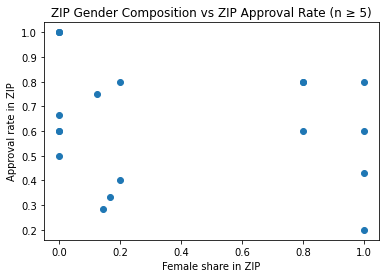

In [83]:
plt.figure(figsize=(6, 4))
plt.scatter(zip_proxy_filtered["female_share"], zip_proxy_filtered["approval_rate"])
plt.xlabel("Female share in ZIP")
plt.ylabel("Approval rate in ZIP")
plt.title(f"ZIP Gender Composition vs ZIP Approval Rate (n ≥ {MIN_N})")
plt.show()

### Most female-heavy and male-heavy ZIP codes in the filtered sample

In [ ]:
high_female = zip_proxy_filtered.sort_values("female_share", ascending=False).head(10)
low_female = zip_proxy_filtered.sort_values("female_share", ascending=True).head(10)

print("ZIP codes with highest female share:")
display(high_female)
print(f"Average approval rate (highest female-share ZIPs): {high_female['approval_rate'].mean():.3f}")
print()

print("ZIP codes with lowest female share:")
display(low_female)
print(f"Average approval rate (lowest female-share ZIPs): {low_female['approval_rate'].mean():.3f}")

ZIP codes with highest female share:


,count,approval_rate,female_share
applicant_info_zip_code,,,
90284.0,7,0.428571,1.000000
90252.0,5,0.800000,1.000000
90237.0,5,0.600000,1.000000
90205.0,5,0.200000,1.000000
90273.0,5,0.600000,0.800000
90261.0,5,0.800000,0.800000
90218.0,5,0.800000,0.800000
10003.0,5,0.400000,0.200000
10070.0,5,0.800000,0.200000


Average approval rate (highest female-share ZIPs): 0.576

ZIP codes with lowest female share:


,count,approval_rate,female_share
applicant_info_zip_code,,,
10002.0,5,0.600000,0.000000
10004.0,6,1.000000,0.000000
10012.0,5,1.000000,0.000000
10020.0,6,0.666667,0.000000
10041.0,5,0.600000,0.000000
10057.0,6,0.500000,0.000000
10092.0,5,1.000000,0.000000
10048.0,8,0.750000,0.125000
10096.0,7,0.285714,0.142857


Average approval rate (lowest female-share ZIPs): 0.674


## Interpretation of ZIP Code Proxy Analysis

After filtering to ZIP codes with at least 5 applications, 19 ZIP codes remain in the analysis. Approval rates across these ZIP codes vary substantially, ranging from about **0.20 to 1.00**. This indicates that lending outcomes differ across geographic areas in the dataset.

To explore whether ZIP code could act as a proxy for gender, the analysis compared the **gender composition of each ZIP code** with the **approval rate in that ZIP code**. The correlation between the female share of applicants and the approval rate across ZIP codes is **−0.22**, which indicates a weak negative relationship.

The scatter plot also shows no clear linear pattern between the proportion of female applicants in a ZIP code and the approval rate. Some ZIP codes with a high female share have both relatively high and relatively low approval rates.

Overall, the results suggest that **ZIP code is associated with variation in approval outcomes**, but there is **no strong evidence that ZIP code is acting as a proxy for gender in this dataset**. The relatively small number of applications per ZIP code also means that these patterns should be interpreted with some caution.

In [87]:
df_corr = df_bias.copy()
df_corr["approved_int"] = df_corr["decision_loan_approved"].astype(int)

numeric_cols = df_corr.select_dtypes(include="number").columns.tolist()
numeric_cols = [col for col in numeric_cols if col != "approved_int"]

corr_results = []

for col in numeric_cols:
    valid = df_corr[[col, "approved_int"]].dropna()
    if len(valid) >= 30:
        corr_value = valid[col].corr(valid["approved_int"])
        corr_results.append((col, corr_value, len(valid)))

corr_table = (
    pd.DataFrame(corr_results, columns=["feature", "correlation_with_approval", "n"])
    .sort_values("correlation_with_approval", key=lambda s: s.abs(), ascending=False)
)

display(corr_table)

/Users/oleeiane/opt/anaconda3/lib/python3.9/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/oleeiane/opt/anaconda3/lib/python3.9/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/oleeiane/opt/anaconda3/lib/python3.9/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/oleeiane/opt/anaconda3/lib/python3.9/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,feature,correlation_with_approval,n
1,financials_annual_income,0.178610,494
2,financials_credit_history_months,0.140888,500
4,financials_savings_balance,0.133481,499
7,age_years,0.123885,495
0,applicant_info_zip_code,-0.123682,498
3,financials_debt_to_income,-0.007757,499
5,decision_interest_rate,NaN,292
6,decision_approved_amount,NaN,292


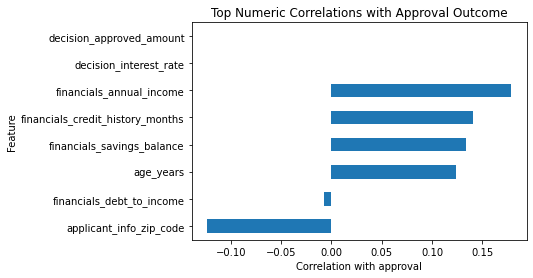

In [88]:
top_corrs = corr_table.head(10).sort_values("correlation_with_approval")

ax = top_corrs.plot(
    kind="barh",
    x="feature",
    y="correlation_with_approval",
    legend=False
)

ax.set_xlabel("Correlation with approval")
ax.set_ylabel("Feature")
ax.set_title("Top Numeric Correlations with Approval Outcome")
plt.show()

### Comment

The correlation scan highlights which numeric variables are most associated with loan approval outcomes in the dataset.

The strongest positive correlations with approval are **annual income (0.179)**, **credit history length (0.141)**, and **savings balance (0.133)**. This suggests that applicants with higher income, longer credit histories, and larger savings balances tend to have slightly higher approval rates.

Age also shows a small positive correlation (**0.124**), indicating that older applicants are somewhat more likely to receive approvals, although the relationship is relatively weak.

ZIP code shows a small negative correlation with approval (**-0.124**), which is consistent with the earlier proxy analysis showing that approval rates vary across geographic areas.

Overall, the correlations are relatively small in magnitude, meaning that no single variable alone strongly determines approval decisions. Instead, approval outcomes likely depend on a combination of financial and demographic factors.

## Bias analysis summary

The table below brings together the main results from the bias and fairness analysis.

In [89]:
summary = {
    "Female approval rate": gender_rates.get("Female", np.nan),
    "Male approval rate": gender_rates.get("Male", np.nan),
    "Disparate Impact (Female/Male)": di_female_over_male,
    "Four-fifths rule triggered": di_flag,
    "ZIP female-share correlation": zip_gender_corr if "zip_gender_corr" in locals() else np.nan
}

pd.Series(summary)

Female approval rate                 0.508
Male approval rate                0.659919
Disparate Impact (Female/Male)    0.769791
Four-fifths rule triggered            True
ZIP female-share correlation      -0.22206
dtype: object